In [1]:
import os

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

from datatree import open_datatree
from var_assim.config import DATA_DIR_ABS
from var_assim.plotting.presets import get_presets

In [2]:
presets, basefile = get_presets()
plt.rcParams.update(presets)

In [3]:
model = 'pco2geowc'
prefix = 'margobs_ws'
ssp = 'ssp245'
TMIN = 2025
th = '14'
ECS = 3.0
DEGpDEC = 0.1
NYRSRAMP = 50
Nwinds = '14custom'
Nens = 500
noise_model = 'AR1'

fname = DATA_DIR_ABS / "output" / model / (
        f"{prefix}_{ssp}_{model}_TMIN{TMIN}_{noise_model}_THETA{th}_ECS{ECS}_DEGpDEC{DEGpDEC}_NYRSRAMP{NYRSRAMP}_Nwinds{Nwinds}_Nens{Nens}.nc"
    )

dt = open_datatree(fname, engine='netcdf4')

In [15]:
ds = dt['2027']
ds2 = dt['2100']

In [18]:
l_prior = ds.controls_hist.sel(vari='L', iter=1).values
l_prior2 = ds2.controls_hist.sel(vari='L', iter=1).values

(array([  8.,  16.,  40., 113., 123.,  82.,  60.,  15.,  10.,   5.]),
 array([0.43088209, 0.58225183, 0.73362156, 0.88499129, 1.03636102,
        1.18773075, 1.33910048, 1.49047021, 1.64183994, 1.79320967,
        1.9445794 ]),
 <BarContainer object of 10 artists>)

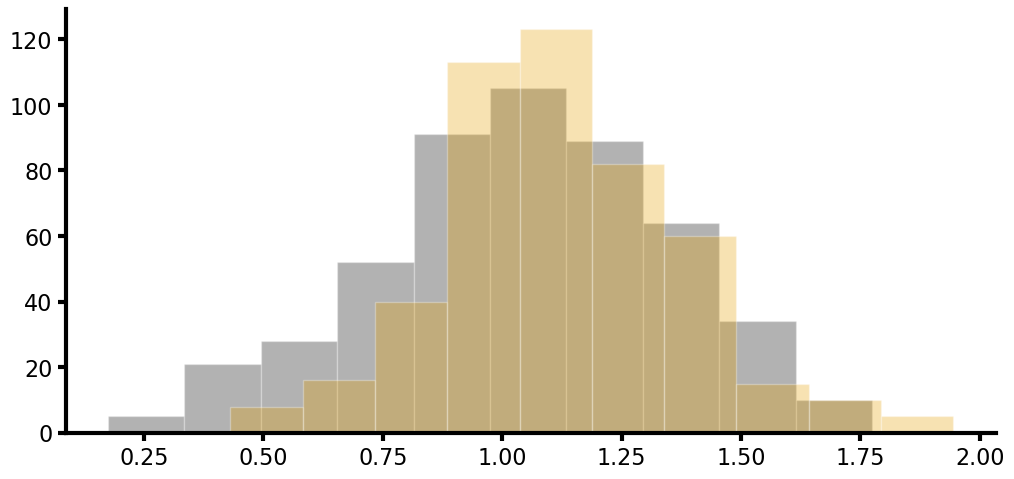

In [21]:
plt.hist(l_prior[l_prior < 2], alpha=0.3)
plt.hist(l_prior2[l_prior2 < 2], alpha=0.3)